In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
import os
from IPython.display import Latex
from scipy import constants
import pandas as pd
from pandas import DataFrame
from time import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e

In [3]:
from pairinteraction.visualization.colormaps import alphamagma

colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   


n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [20]:
# Choosing channel from list and mj values
channel = 3

theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 1, 0

m1_1s, m2_1s = np.arange(-j1_1, j1_1+1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = -1, -1

btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))
btunes = np.append([0], btunes)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining arc calculation
calc = arc.PairStateInteractions(arc_atom1, n1_0, l1_0, j1_0, n2_0, l2_0, j2_0, m1=m1_0s[m1_i], m2=m2_0s[m2_i], interactionsUpTo = 2, s=1/2, s2=1/2, atom2 = arc_atom2)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j), m=(ket1.m,ket1.m))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))


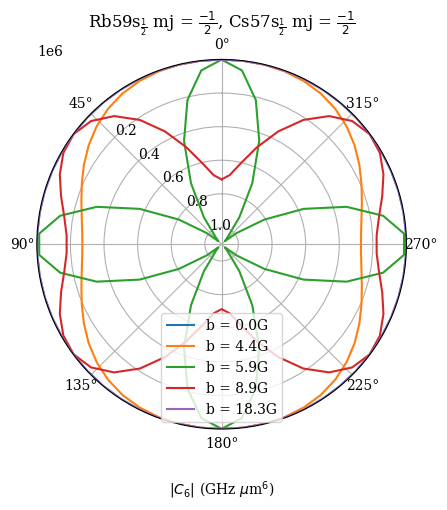

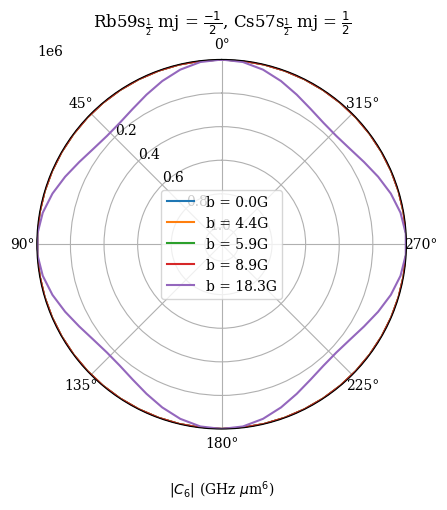

In [ ]:
thetaList = np.linspace(0, 360, 55)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular C6\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\angular C6\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'
if not os.path.exists(datapath):
    os.makedirs(datapath)
r=1000
m1 = -1/2
m1s, m2s, thetas, c6s = [], [], [], []
for m2 in m2_0s:
    fig, ax = plt.subplots(1, subplot_kw={'projection': 'polar'})

    ax.set_theta_zero_location("N")
    ax.set_title(fr'{atom1}{n1_0}{orbs[l1_0]}$_\frac{{{int(2*j1_0)}}}{{2}}$ mj = $\frac{{{int(2*m1)}}}{{2}}$, {atom2}{n2_0}{orbs[l2_0]}$_\frac{{{int(2*j2_0)}}}{{2}}$ mj = $\frac{{{int(2*m2)}}}{{2}}$')
    ax.set_xlabel(r'$|C_6|$ (GHz $\mu$m$^{6}$)', labelpad=20)
    ax.set_rlabel_position(45)
    ax.set_rlim(0,1.1e6)

    for b in btunes:
        # Defining arc calculation
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1, j=j1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2, j=j2_0)
        C6 = pi.C6(ket1_0, ket2_0)
        C6.set_magnetic_field([0,0,b], unit='G')
        C6.set_minimum_number_of_ket_pairs(5000)
        C6.set_diamagnetism_enabled(True)
        m1s.append(m1)
        m2s.append(m2)
        line = []
        c6 = []
        for t in thetaList:
            C6.set_distance(r, unit='micrometer', angle_degree=t)
            c6.append(abs(C6.get(unit="planck_constant * GHz * micrometer^6")))
            
        # plot results
        ax.plot(
            np.radians(thetaList), c6, "-", label=(f'b = {np.round(b,1)}G')
        )
        angData = {'theta' : thetaList, 'c6' : c6}
        pd.DataFrame(angData).to_csv(datapath + f'\\{n1_0}mj({m1}), {n2_0}mj({m2}).csv', index=False)


    plt.legend(fontsize=10)

    plt.savefig(figpath + f'\\mjs{m1},{m2}.png')
plt.show()


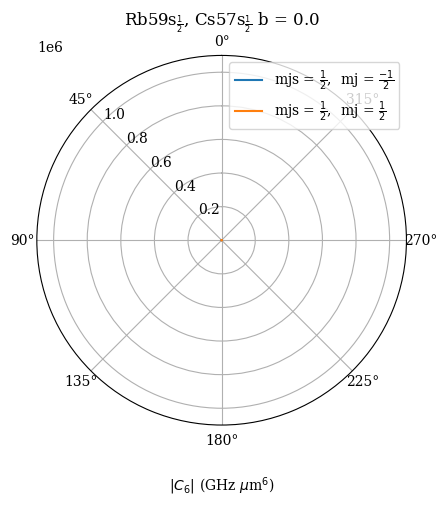

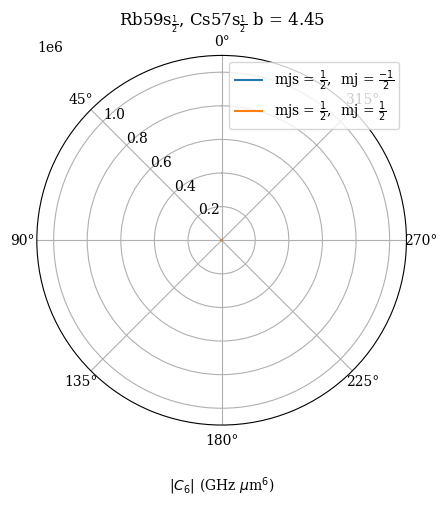

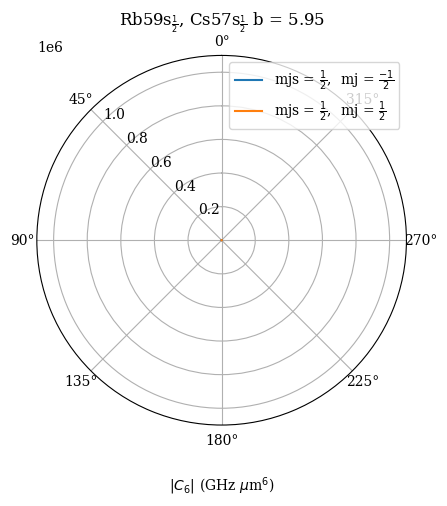

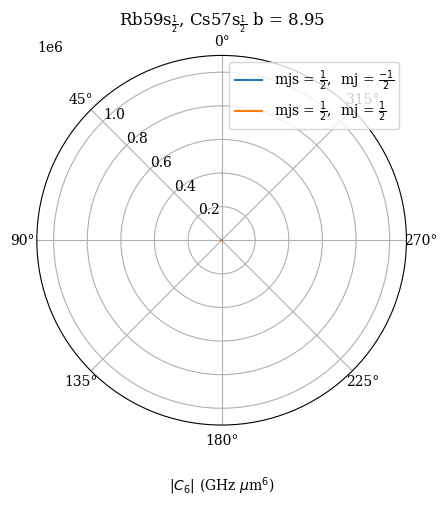

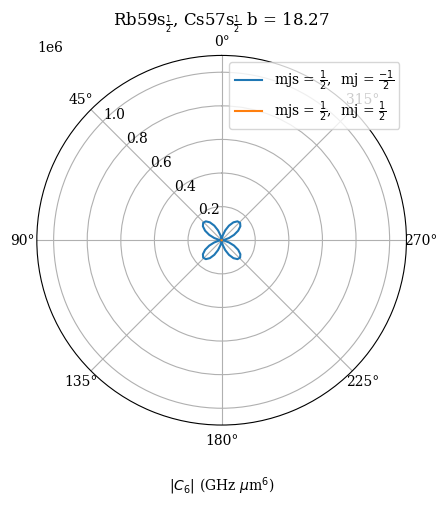

In [51]:
# Same except different plots show different bs
thetaList = np.linspace(0, 360, 55)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular C6\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\angular C6\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})'
if not os.path.exists(datapath):
    os.makedirs(datapath)
r=1000
m1 = 1/2
m1s, m2s, thetas, c6s = [], [], [], []

for b in btunes:
    fig, ax = plt.subplots(1, subplot_kw={'projection': 'polar'})

    ax.set_theta_zero_location("N")
    ax.set_title(fr'{atom1}{n1_0}{orbs[l1_0]}$_\frac{{{int(2*j1_0)}}}{{2}}$, {atom2}{n2_0}{orbs[l2_0]}$_\frac{{{int(2*j2_0)}}}{{2}}$ b = {np.round(b,2)}')
    ax.set_xlabel(r'$|C_6|$ (GHz $\mu$m$^{6}$)', labelpad=20)
    ax.set_rlabel_position(45)
    ax.set_rlim(0, 1.1e6)

    for m2 in m2_0s:
        # Defining arc calculation
        ket1_0 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1, j=j1_0)
        ket2_0 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2, j=j2_0)
        C6 = pi.C6(ket1_0, ket2_0)
        C6.set_magnetic_field([0,0,b], unit='G')
        C6.set_minimum_number_of_ket_pairs(2000)
        C6.set_diamagnetism_enabled(True)
        m1s.append(m1)
        m2s.append(m2)
        line = []
        c6 = []
        for t in thetaList:
            C6.set_distance(r, unit='micrometer', angle_degree=t)
            c6.append(abs(C6.get(unit="planck_constant * GHz * micrometer^6")))
            
        # plot results
        ax.plot(
            np.radians(thetaList), c6, "-", label=(fr'mjs = $\frac{{{int(2*m1)}}}{{2}}$,  mj = $\frac{{{int(2*m2)}}}{{2}}$')
        )
        angData = {'theta' : thetaList, 'c6' : c6}
        pd.DataFrame(angData).to_csv(datapath + f'\\{n1_0}mj({m1}), {n2_0}mj({m2}).csv', index=False)


    plt.legend(fontsize=10)

    plt.savefig(figpath + f'\\b = {np.round(b,2)}.png')
plt.show()


In [64]:
angData = (m1s, m2s, thetas, c6s)
print(pd.DataFrame(angData)[0][3][0])


32557.632993625946


C:\Users\Tommy\AppData\Local\Temp\ipykernel_5644\2487819138.py:11: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(thetaList, c6, "-", label=("mj1=%d/2" % int(2 * m1), "mj2=%d/2" % int(2 * m2)))


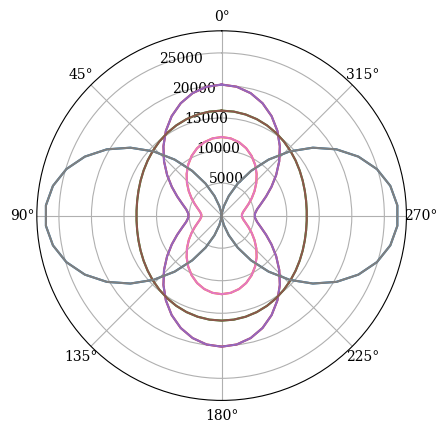

In [85]:
# Plot data from file
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")

for m1 in m1_0s:
    for m2 in m2_0s:
        data = pd.read_csv(datapath + f'\\{n1_0}mj({m1}), {n2_0}mj({m2}).csv')
        thetas = data['theta']
        c6 = data['c6']

        ax.plot(thetaList, c6, "-", label=("mj1=%d/2" % int(2 * m1), "mj2=%d/2" % int(2 * m2)))


In [86]:
# Calculate C6 coefficients for different angles
c6_obj = pi.C6(ket1, ket2)
c6_obj.set_diamagnetism_enabled(False)
c6_obj.set_magnetic_field([0, 0, 20], "gauss")

thetas = np.linspace(0, 2 * np.pi, 40)
c6_coeffs = [c6_obj.set_angle(theta, unit="radian").get("GHz um^6") for theta in thetas]

# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[1].remove()
axs[1] = fig.add_subplot(1, 2, 2, projection="polar")

for ax in axs:
    ax.scatter(thetas, c6_coeffs, label="perturbative C6")
    ax.plot(
        thetas,
        -0.5 * c6_coeffs[0] * (1 - 3 * np.cos(thetas) ** 2),
        label=r"$1-3\cos(\theta)^2$",
    )

axs[0].legend()
axs[0].set_xlabel(r"$\theta$ [rad]")
axs[0].set_ylabel(r"$C_6$ [$h$ GHz $\mu m^6$]")

plt.show()

ValueError: If you want to calculate 2nd order perturbations of two different states a and b (of the same species), please use the EffectiveSystemPair([(a,b), (b,a)]) class.

The ket |~Rb:61,P_1/2,1/2; ~Rb:61,P_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |~Rb:61,P_1/2,1/2; ~Rb:61,P_3/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:61,P_1/2,1/2; ~Rb:61,P_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |~Rb:61,P_1/2,1/2; ~Rb:61,P_3/2,-1/2⟩ with overlap 1.000e+00
The ket |~Rb:61,P_1/2,1/2; ~Rb:61,P_1/2,1/2⟩ has only 0.000 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |~Rb:61,P_1/2,1/2; ~Rb:61,P_3/2,-1/

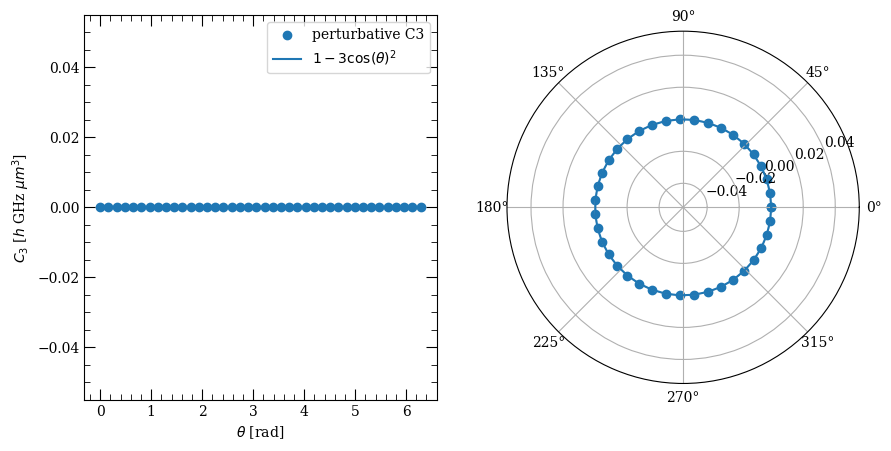

In [ ]:
# Calculate C3 coefficients for different angles
c3_obj = pi.C3(ket1, ket2)
c3_obj.set_diamagnetism_enabled(False)
c3_obj.set_magnetic_field([0, 0, 20], "gauss")

thetas = np.linspace(0, 2 * np.pi, 40)
c3_coeffs = [c3_obj.set_angle(theta, unit="radian").get("GHz um^3") for theta in thetas]

# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[1].remove()
axs[1] = fig.add_subplot(1, 2, 2, projection="polar")

for ax in axs:
    ax.scatter(thetas, c3_coeffs, label="perturbative C3")
    ax.plot(
        thetas,
        -0.5 * c3_coeffs[0] * (1 - 3 * np.cos(thetas) ** 2),
        label=r"$1-3\cos(\theta)^2$",
    )

axs[0].legend()
axs[0].set_xlabel(r"$\theta$ [rad]")
axs[0].set_ylabel(r"$C_3$ [$h$ GHz $\mu m^3$]")

plt.show()

In [69]:
import pairinteraction as pi
def get_system_pair_list(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, ket1_1s, ket2_1s, b_field, d, erange, thetas
) -> list[pi.SystemPair]:
    b = b_field

    dif=2

    basis1 = pi.BasisAtom(atom1, n=(ket1.n - dif, ket1.n), l=(0,ket1.l + dif), j=(ket1.j,ket1.j + dif), m=(-ket1.j - dif, ket1.j + dif), additional_kets=ket1_1s)

    basis2 = pi.BasisAtom(atom2, n=(ket2.n - dif, ket2.n), l=(0,ket2.l + dif), j=(ket2.j,ket2.j + dif), m=(-ket2.j - dif, ket2.j + dif), additional_kets=ket2_1s)

    pair_systems = []
    for i, theta in enumerate(thetas):
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,b], unit='G'), pi.SystemAtom(basis2).set_magnetic_field([0,0,b], unit='G')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um', angle_degree=theta)
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")

    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num 

In [ ]:
atom1, atom2 = 'Rb', 'Rb'
n1, n2 = 60, 60
l1, l2 = 1, 1
j1, j2 = 1/2, 1/2

n1_1, n2_1 = 60, 60
l1_1, l2_1 = 0, 0
j1_1, j2_1 = 1/2, 1/2

b=0
thetas = np.linspace(0, 2 * np.pi, 400)

ket1, ket2 = pi.KetAtom(atom1, n=n1, l=l1, j=j1, m=j1), pi.KetAtom(atom2, n=n2, l=l2, j=j2, m=j2)
ket1_energy, ket2_energy = ket1.get_energy(energy_unit), ket2.get_energy(energy_unit)

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)

ket1_1s, ket2_1s = [], []
ms1 = np.arange(-ket1_1.j, ket1_1.j+1)
ms2 = np.arange(-ket2_1.j, ket2_1.j+1)

for m1, m2 in zip(ms1, ms2):

    ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=m2)
    ket1_1s.append(ket1_1)
    ket2_1s.append(ket2_1)

print(ket1_1s)
defect = ket1_1.get_energy(energy_unit) + ket2_1.get_energy(energy_unit) - ket1.get_energy(energy_unit) - ket2.get_energy(energy_unit)

r = [4]
bfield = 0  # Gauss
erange = abs(defect + defect*20)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
for d in r:
    pairs = get_system_pair_list(ket1, ket2, ket1_1s, ket2_1s, b, d, erange, thetas)
    system_pairs_dict[d] = pairs[0]
    states_num = pairs[1]

[KetAtom(Rb:60,S_1/2,-1/2), KetAtom(Rb:60,S_1/2,-1/2), KetAtom(Rb:60,S_1/2,1/2), KetAtom(Rb:60,S_1/2,1/2)]


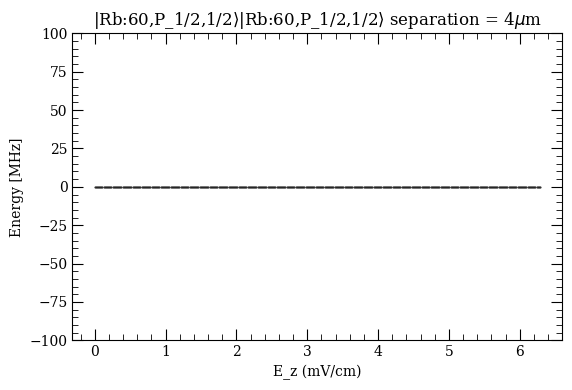

In [ ]:
for i, d in enumerate(r):
    fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
    ax.set_xlabel("E_z (mV/cm)")
    ax.set_ylabel(f"Energy ({energy_unit})")
    ax.set_title(fr'separation {d} $\mu$m')
    # ax.set_ylim(-0.01, 0.01)

    # system_atom = system_atom_dict[efield]
    pair_energy = ket1_energy + ket2_energy
    system_pairs = system_pairs_dict[d]


    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    
    overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]

    # ax.plot(e_fields_sub, energies)
    for x, es in zip(thetas, energies):
        plt.plot([x] * len(es), es, c='.1', ls="None", marker=".", ms=1, zorder=-1)

    plt.tight_layout()
    min_energy = -100
    max_energy = 100
    plt.title(fr'{str(ket1)}{str(ket2)} separation = {d}$\mu$m')
    plt.ylim(min_energy, max_energy)
    # plt.xlim(.2, .2.7)
    plt.ylabel(f"Energy [{energy_unit}]")
    
    
    plt.show()
    # fig.savefig(path + f'level pairstate sep{r}.png')

In [3]:
# ARC separated angular calculation
import arc
from inspect import getmodule as inspectgetmodule
from arc import PairStateInteractions
import h5py 
energyDelta = 1e10
nValueRange = [20,30]
nRange=3
stateHop = False

l1_0 = 1
calc = arc.PairStateInteractions(arc_atom1, n1_0, l1_0, j1_0, n2_0, l2_0, j2_0, m1=j1_0, m2=j2_0, interactionsUpTo = 2, s=1/2, s2=1/2, atom2 = arc_atom2)


atomInfos, coupledStates, data = calc.loadAngularChannelData([l1_0, j1_0, 1/2, arc.Rubidium()], [l2_0, j2_0, 1/2, arc.Rubidium()], loadFromZenodo=True)

# calculate data and save in file
t1 = time()
status = calc.calculateAngularChannelData([l1_0, j1_0, 0.5, arc.Rubidium()], [l2_0, j2_0, 0.5, arc.Rubidium()], nValueRange, nRange, energyDelta, stateHopping=stateHop, overwriteLocalData=True)
t2 = time()
print('angular channel dataset precalculation, success?', status)
print('time requirement for calculation of {:.0f} pair state data: {:.1f} s.'.format((nValueRange[1]-nValueRange[0]+1)**2, t2-t1))


print(data.shape)
data = np.reshape(data, (nValueRange[1]-nValueRange[0]+1, nValueRange[1]-nValueRange[0]+1, np.shape(data)[1]))


print(coupledStates)
# calc.calculateAngularChannelData([l1_0, j1_0, 1/2, arc.Rubidium()], [l2_0, j2_0, 1/2, arc.Rubidium()], nValueRange=[n1_0-3, n1_0+3], nRange = 3, energyDelta=1e10, overwriteLocalData=False)


NameError: name 'arc_atom1' is not defined

In [4]:
# c6s=[]
# thetas=np.linspace(0, 2*np.pi)
# for theta in thetas:
    
#     c6 = calc.getC6perturbativelyAngularChannel(theta, 0, nRange=3, energyDelta=energyDelta, degeneratePerturbation=False, returnInteractionMatrix=False)
#     c6s.append(c6)


# ax = plt.subplot(111, projection="polar")
# ax.set_theta_zero_location("N")
# line = []

# plot results
(lineLegend,) = plt.plot(
    thetas, c6s, "-", color="r", label=("mj=%d/2" % int(2 * j1_0))
)
line.append(lineLegend)

plt.legend(handles=line, fontsize=10)
plt.title(
    f"{atom1}{atom2}, pairstate  {n1_0}{orbs[l1_0]}{j1_0}, {n2_0}{orbs[l2_0]}{j2_0}, $|C_6|$ in GHz $\\mu$m$^{6}$", fontsize=10
)
plt.show()

NameError: name 'thetas' is not defined

[0.5, 1.5]
0.5 2.5


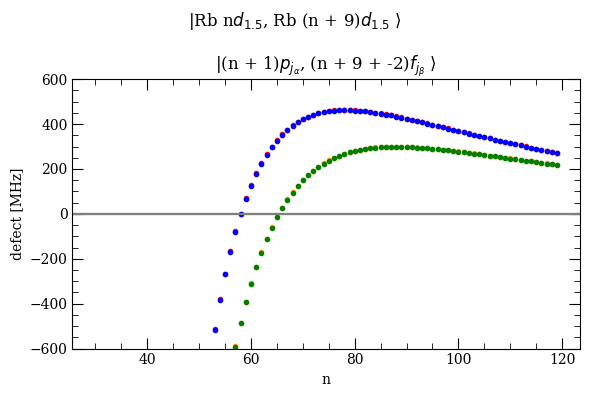

In [4]:
import os
dif = n2 - n1
change1 = n1_1 - n1
change2 = n2_1 - n2
jpdelta1 = []
jpdelta2 = []

min_n = 30
max_n = 120
ns = np.arange(min_n,max_n)
js = ([1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2])

jss = [1/2]
jps = [1/2, 3/2]
jds = [3/2, 5/2]
jfs = [5/2, 7/2]

jpdelta1 = []
jpdelta2 = []
labels = []
print(js[l1_1])
for j_a in js[l1_1]:
    
    for j_b in js[l2_1]:

        delta1 = []
        delta2 = []

        for n in ns:
            nb = n+dif
            
            # Rb lowering n
            state1 = pi.KetAtom(atom1, n=n, l=l1, j=j1, m=j1, s=1/2)
            state2 = pi.KetAtom(atom2, n=nb, l=l1, j=j2, m=j2, s=1/2)
            state1_1 = pi.KetAtom(atom1, n=n+change1, l=l1_1, j=j_a, m=j_a, s=1/2)
            state2_1 = pi.KetAtom(atom2, n=nb+change2, l=l2_1, j=j_b, m=j_b, s=1/2)
            
            defect_1 = state1_1.get_energy(energy_unit) - state1.get_energy(energy_unit)
            defect_2 = state2_1.get_energy(energy_unit) - state2.get_energy(energy_unit)
            defect = defect_1 + defect_2
            delta1.append(defect)
        
        jpdelta1.append(delta1)
        if state1_1.j == j1_1 and state2_1.j == j2_1:
            print(state1_1.j, state2_1.j)
            min_defect = delta1[list(ns).index(n1)]

        labels.append(str(j_a) + ', ' + str(j_b))
        
fig = plt.figure(figsize = (6,4))

plt.title(fr'|(n + {change1})${orbs[l1_1]}_{{j_\alpha}}$, (n + {dif} + {change2})${orbs[l2_1]}_{{j_\beta}}$ $\rangle$')
plt.ylabel(f'defect [{energy_unit}]')

plt.xlabel('n')

for i, data in enumerate(jpdelta1):

    plt.scatter(ns, data, marker='.', label = fr'$j_\alpha$, $j_\beta$ = {labels[i]}', color=colours[i])
    
    plt.axhline(0, color='grey')

    # axs[0, change2].legend()
    plt.ylim((-600,600))
    # plt.xlim((60,120))

fig.suptitle(fr'|Rb n${orbs[l1]}_{{{j1}}}$, Rb (n + {dif})${orbs[l2]}_{{{j2}}}$ $\rangle$')
# fig.suptitle(fr'|Rb n$S_{{1/2}}$, Rb (n + {dif})$S_{{1/2}}$ $\rangle \rightarrow$' + '\n' +
#               fr'|Rb [n + (n change 1)]$P_{{j_p}}$, Rb [(n + {dif}) + (n change 2)]$P_{{j_p}}$ $\rangle$')
# fig.subplots_adjust(top=0.8, left=.1, right=2.7)
plt.tight_layout()
path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{n1}{orbs[l1]}_{j1} {n2}{orbs[l2]}_{j2}\\'

if not os.path.exists(path):
    os.makedirs(path)
# plt.savefig(path + f'defect plot.png')
plt.show()

In [5]:
print(min_defect)

-13.190686225891113


[StateAtom(1.00 |Rb:62,S_1/2,-1/2⟩), StateAtom(1.00 |Rb:62,S_1/2,1/2⟩), StateAtom(1.00 |Rb:62,P_1/2,-1/2⟩), StateAtom(1.00 |Rb:62,P_1/2,1/2⟩), StateAtom(1.00 |Rb:62,P_3/2,-3/2⟩), StateAtom(1.00 |Rb:62,P_3/2,-1/2⟩), StateAtom(1.00 |Rb:62,P_3/2,1/2⟩), StateAtom(1.00 |Rb:62,P_3/2,3/2⟩), StateAtom(1.00 |Rb:63,S_1/2,-1/2⟩), StateAtom(1.00 |Rb:63,S_1/2,1/2⟩), StateAtom(1.00 |Rb:63,P_1/2,-1/2⟩), StateAtom(1.00 |Rb:63,P_1/2,1/2⟩), StateAtom(1.00 |Rb:63,P_3/2,-3/2⟩), StateAtom(1.00 |Rb:63,P_3/2,-1/2⟩), StateAtom(1.00 |Rb:63,P_3/2,1/2⟩), StateAtom(1.00 |Rb:63,P_3/2,3/2⟩), StateAtom(1.00 |Rb:62,D_3/2,-3/2⟩), StateAtom(1.00 |Rb:62,D_3/2,-1/2⟩), StateAtom(1.00 |Rb:62,D_3/2,1/2⟩), StateAtom(1.00 |Rb:62,D_3/2,3/2⟩), StateAtom(1.00 |Rb:62,D_5/2,-5/2⟩), StateAtom(1.00 |Rb:62,D_5/2,-3/2⟩), StateAtom(1.00 |Rb:62,D_5/2,-1/2⟩), StateAtom(1.00 |Rb:62,D_5/2,1/2⟩), StateAtom(1.00 |Rb:62,D_5/2,3/2⟩), StateAtom(1.00 |Rb:62,D_5/2,5/2⟩), StateAtom(1.00 |Rb:64,S_1/2,-1/2⟩), StateAtom(1.00 |Rb:64,S_1/2,1/2⟩), State

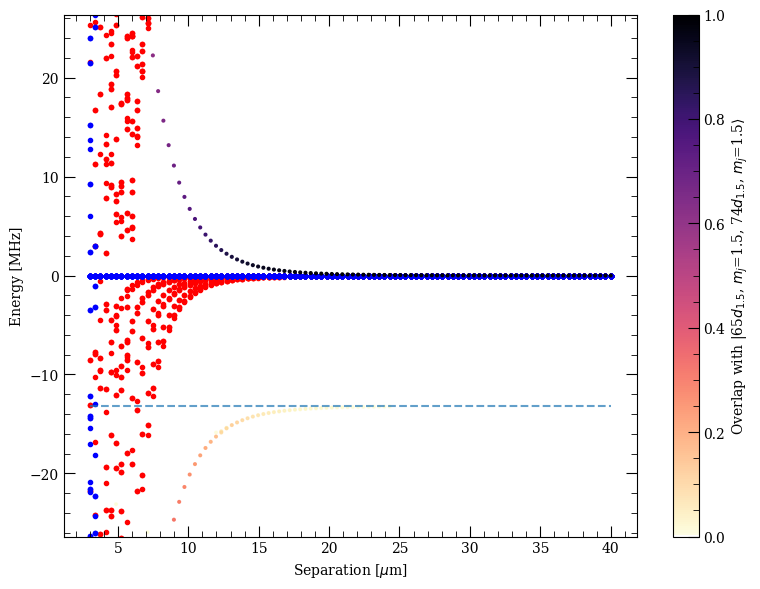

In [7]:
r = np.linspace(3, 40, 100)
tune=0.73
# es = 199.8*tune/200, 199.9*tune/200, tune, 200.1*tune/200
es=[0]
energy_dif = abs(2000)
fig, ax = plt.subplots(len(es),1, sharex=True, figsize = (8,6))
for i, elec in enumerate(es):
    system1 = pi.SystemAtom(basis1).set_electric_field([0,0, elec], unit='V/cm')
    system2 = pi.SystemAtom(basis2).set_electric_field([0,0, elec], unit='V/cm')
    pi.diagonalize((system1, system2), diagonalizer="eigen", sort_by_energy=True)
    
    print(basis1.states)
    print(ket1)
    interpair_energy = ket1.get_energy(unit = energy_unit) + ket2.get_energy(unit = energy_unit)
    intrapair1_energy = ket1.get_energy(unit = energy_unit) + ket1.get_energy(unit = energy_unit)
    intrapair2_energy = ket2.get_energy(unit = energy_unit) + ket2.get_energy(unit = energy_unit)

    min_energy, max_energy = interpair_energy - energy_dif, interpair_energy + energy_dif

    inter_basis = pi.BasisPair([system1, system2], energy = (interpair_energy - energy_dif, interpair_energy + energy_dif), energy_unit=energy_unit
    )
    intra1_basis = pi.BasisPair([system1, system1], energy = (intrapair1_energy - energy_dif, intrapair1_energy + energy_dif), energy_unit=energy_unit
    )
    intra2_basis = pi.BasisPair([system2, system2], energy = (intrapair2_energy - energy_dif, intrapair2_energy + energy_dif), energy_unit=energy_unit
    )

    inter_systems = [
        pi.SystemPair(inter_basis).set_distance(d, unit="micrometer") for d in r
    ]
    intra1_systems = [
        pi.SystemPair(intra1_basis).set_distance(d, unit="micrometer") for d in r
    ]
    intra2_systems = [
        pi.SystemPair(intra2_basis).set_distance(d, unit="micrometer") for d in r
    ]

    pi.diagonalize(inter_systems, diagonalizer="eigen", sort_by_energy=True)
    pi.diagonalize(intra1_systems, diagonalizer="eigen", sort_by_energy=True)
    pi.diagonalize(intra2_systems, diagonalizer="eigen", sort_by_energy=True)

    eigenenergies_inter = [system.get_eigenenergies(unit=energy_unit) - interpair_energy for system in inter_systems]
    eigenenergies_intra1 = [system.get_eigenenergies(unit=energy_unit) - intrapair1_energy for system in intra1_systems]
    eigenenergies_intra2 = [system.get_eigenenergies(unit=energy_unit) - intrapair2_energy for system in intra2_systems]

    overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in inter_systems]
    ylim =abs(min_defect*2)
    offset = 0

    ax.set_ylabel(f"Energy [{energy_unit}]")
    ax.set_ylim(-ylim+offset, ylim+offset)

    try:
        ax.scatter(r, np.array(eigenenergies_inter), c='0', lw=0.25)
        ax.scatter(r, np.array(eigenenergies_intra1), c="r", lw=0.25)
        ax.scatter(r, np.array(eigenenergies_intra2), c="b", lw=0.25)
    except ValueError:  # inhomogeneous shape -> no simple line plot possible
        # for x, es in zip(r, eigenenergies_inter):
        #     ax.plot([x] * len(es), es, ls="None", marker=".", c='0', zorder=-10)
        for x, es in zip(r, eigenenergies_intra1):
            ax.plot([x] * len(es), es, ls="None", marker=".", c='r', zorder=-10)
        for x, es in zip(r, eigenenergies_intra2):
            ax.plot([x] * len(es), es, ls="None", marker=".", c='b', zorder=-10)

    x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(r, eigenenergies_inter)])
    energies_flattened = np.hstack(eigenenergies_inter)
    overlaps_flattened = np.hstack(overlaps)
    sorter = np.argsort(overlaps_flattened)

    scat = ax.scatter(
        x_repeated[sorter],
        energies_flattened[sorter],
        c=overlaps_flattened[sorter],
        s=15,
        vmin=0,
        vmax=1,
        cmap=alphamagma,
        marker = '.'
    )

    ax.hlines((-energy_dif, energy_dif, min_defect), xmin=r[0], xmax=r[-1], linestyle='dashed', alpha = 0.7)
ax.set_xlabel(r"Separation [$\mu$m]")
fig.colorbar(scat, ax=ax, label=fr"Overlap with |{ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$={ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$={ket2.m}$\rangle$", cmap = 'plasma')
fig.tight_layout()
plt.show()
# fig.savefig(path + 'level diags')

[   0    1 6000 ... 7174 7186 7198]


C:\Users\Tommy\AppData\Local\Temp\ipykernel_29596\2302087560.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  scat = ax.scatter(


(600,)


C:\Users\Tommy\AppData\Local\Temp\ipykernel_29596\2302087560.py:79: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim((0,25))


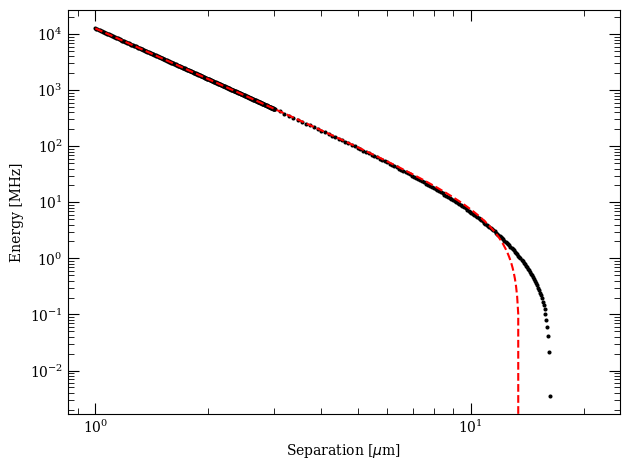

c_3 = 12.647731536218021 $\pm$ 0.0005180082061294522 GHz $\mu m$


In [19]:
r = np.append(np.linspace(1, 3, 300), np.linspace(3.01, 30, 300))
tune=0.025


energy_dif = abs(min_defect*4)
fig, ax = plt.subplots(1,1)
ax.set_yscale('log')
ax.set_xscale('log')

system1 = pi.SystemAtom(basis1).set_electric_field([0,0, tune], unit='V/cm')
system2 = pi.SystemAtom(basis2).set_electric_field([0,0, tune], unit='V/cm')
pi.diagonalize((system1, system2), diagonalizer="eigen", sort_by_energy=True)

pair_energy = ket1.get_energy(unit = energy_unit) + ket2.get_energy(unit = energy_unit)
min_energy, max_energy = pair_energy - energy_dif, pair_energy + energy_dif

pair_basis = pi.BasisPair([system1, system2], energy = (min_energy, max_energy), energy_unit=energy_unit
)

pair_systems = [
    pi.SystemPair(pair_basis).set_distance(d, unit="micrometer") for d in r
]

pi.diagonalize(pair_systems, diagonalizer="eigen", sort_by_energy=True)

eigenenergies = [system.get_eigenenergies(unit=energy_unit) - pair_energy for system in pair_systems]
overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in pair_systems]
ylim =abs(2*min_defect)


ax.set_ylabel(f"Energy [{energy_unit}]")
# ax.set_ylim(-ylim, ylim)

x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(r, eigenenergies)])
energies_flattened = np.hstack(eigenenergies)
overlaps_flattened = np.hstack(overlaps)
sorter = np.argsort(overlaps_flattened)
print(sorter)
min_overlap = .1
energy=[]
d=[]
for x, es, os in zip(r, eigenenergies, overlaps):
    inds = np.argwhere(os > min_overlap).flatten()
    inds = inds[np.argsort(os[inds])]

    if len(inds) > 0:
        scat = ax.scatter(
            [x] * len(es[inds]),
            es[inds],
            s=15,
            vmin=0,
            vmax=1,
            c='0',
            marker='.'
            )
    energy.append(np.max(es[inds])) 
    d.append(x)

def flatten(xs):
    result = []
    if isinstance(xs, (list, tuple)):
        for x in xs:
            result.extend(flatten(x))
    else:
        result.append(xs)
    return result

d=np.hstack(d)
energy=np.hstack(energy)
print(np.shape(d))
def func(x, c, a):
    return c/(x)**3 + a
    
popt, pcov = scipy.optimize.curve_fit(func, d, energy)
ax.plot(d, func(d, *popt), linestyle='dashed', color='red')

# ax.hlines((-energy_dif, energy_dif, min_defect), xmin=r[0], xmax=r[-1], linestyle='dashed', alpha = 0.7)
ax.set_xlabel(r"Separation [$\mu$m]")
ax.set_xlim((0,25))
# fig.colorbar(scat, ax=ax, label=fr"Overlap with |{ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$={ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$={ket2.m}$\rangle$", cmap = 'plasma')
fig.tight_layout()
plt.show()
print(fr'c_3 = {popt[0]/1e3} $\pm$ {np.sqrt(np.diag(pcov))[0]/1e3} GHz $\mu m$')


# fig.savefig(path + 'fitted level')

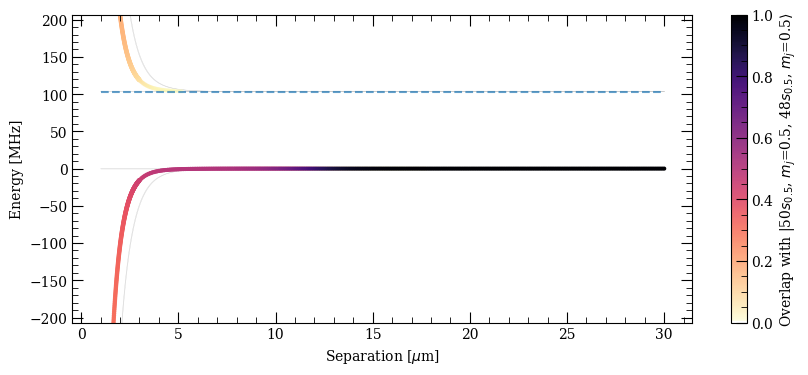

In [46]:
ylim =abs(2*min_defect)
fig, ax = plt.subplots(figsize=(10,4))

ax.set_xlabel(r"Separation [$\mu$m]")
ax.set_ylabel(f"Energy [{energy_unit}]")
ax.set_ylim(-ylim, ylim)

try:
    ax.plot(r, np.array(eigenenergies), c="0.8", lw=0.25, zorder=-10)
except ValueError:  # inhomogeneous shape -> no simple line plot possible
    for x, es in zip(r, eigenenergies):
        ax.plot([x] * len(es), es, c="0.9", ls="None", marker=".", zorder=-10)

x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(r, eigenenergies)])
energies_flattened = np.hstack(eigenenergies)
overlaps_flattened = np.hstack(overlaps)
sorter = np.argsort(overlaps_flattened)

scat = ax.scatter(
    x_repeated[sorter],
    energies_flattened[sorter],
    c=overlaps_flattened[sorter],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma,
    marker = '.'
)

fig.colorbar(scat, ax=ax, label=fr"Overlap with |{ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$={ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$={ket2.m}$\rangle$", cmap = 'plasma')

ax.hlines((-energy_dif, energy_dif, min_defect), xmin=r[0], xmax=r[-1], linestyle='dashed', alpha = 0.7)
plt.show()


In [47]:
fig.savefig(path + 'level diagram')

In [64]:
maxe = 1.4
mine=0
num=1000
electric_fields = np.linspace(mine,maxe,num)

ket1systems = [pi.SystemAtom(ket1basis).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for e in electric_fields
]
pi.diagonalize(ket1systems, diagonalizer="eigen", sort_by_energy=True)
ket1energies = [system.get_eigenenergies(unit=energy_unit) - ket1_energy for system in ket1systems]

systems = [
    pi.SystemAtom(basis1).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for e in electric_fields
]
pi.diagonalize(systems, diagonalizer="eigen", sort_by_energy=True)
eigenenergies1 = [system.get_eigenenergies(unit=energy_unit) - ket1_energy for system in systems]
overlaps1 = [system.get_eigenbasis().get_overlaps(ket1) for system in systems]

ket2systems = [pi.SystemAtom(ket2basis).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for e in electric_fields
]
pi.diagonalize(ket2systems, diagonalizer="eigen", sort_by_energy=True)
ket2energies = [system.get_eigenenergies(unit=energy_unit) - ket2_energy for system in ket2systems]

systems = [
    pi.SystemAtom(basis2).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, -e], unit="V/cm") for e in electric_fields
]
pi.diagonalize(systems, diagonalizer="eigen", sort_by_energy=True)
eigenenergies2 = [system.get_eigenenergies(unit=energy_unit) - ket2_energy for system in systems]
overlaps2 = [system.get_eigenbasis().get_overlaps(ket2) for system in systems]

# Finding defect

ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)

ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
defect = ket1_1.get_energy(energy_unit) + ket2_1.get_energy(energy_unit) - ket1.get_energy(energy_unit) - ket2.get_energy(energy_unit)
    

{'0.7301', '0.6979'}


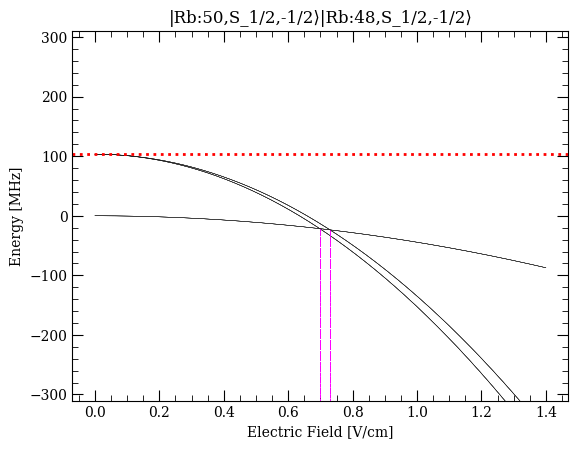

In [65]:
fig = plt.figure()
energy_lim = abs(min_defect + 2*min_defect)
eigenenergies_pair = []
state0s = []

for i, channel1 in enumerate(np.transpose(eigenenergies1)):
    for j, channel2 in enumerate(np.transpose(eigenenergies2)):
        eigenenergy = channel1 + channel2
        if abs(channel1[0]) <= abs(ket1_1.get_energy(energy_unit)-ket1_energy)+2 and abs(channel1[0]) <= abs(ket1_1.get_energy(energy_unit)-ket1_energy)+2:

            eigenenergies_pair.append(eigenenergy)
            if  eigenenergy[0] == 0:
                state0s.append(eigenenergy)
                # print(state0[-1])
min_energy = -energy_lim
max_energy = energy_lim
plt.title(f'{str(ket1)}{str(ket2)}')
plt.ylim(min_energy, max_energy)
plt.ylabel(f"Energy [{energy_unit}]")
plt.xlabel("Electric Field [V/cm]")

tunes=[]

for eigenenergy in eigenenergies_pair:
    plt.plot(electric_fields, eigenenergy, c=".1", lw=0.25)
    if eigenenergy[0] == state0s[0][0]:
        continue
    elif round(defect, 3)-.5 <= round(eigenenergy[0],2) <= round(defect, 3)+.5:

        for state0 in state0s:
            
            energy = eigenenergy-state0
            cross = min(energy, key=abs)
            if abs(cross) < 1:
                index = list(energy).index(cross)
                if index == 0 or index == len(electric_fields)-1:
                    continue
                else:
                    tuned = electric_fields[index]
                    plt.vlines(x=tuned, ymin = min_energy, ymax = eigenenergy[index], linestyles='dashed', colors='magenta', linewidth = 0.5)
                    tunes.append(format(round(tuned, 4), ".15g"))

plt.axhline(min_defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
print(set(tunes))



In [79]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, e_fields: np.ndarray, d, erange
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, e in enumerate(e_fields):
        system1, system2 = pi.SystemAtom(basis1).set_electric_field([0,0,e], unit='V/cm'), pi.SystemAtom(basis2).set_electric_field([0,0,e], unit='V/cm')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um')
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num

def get_system_atom_energies(ez: float, bz: float) -> pi.SystemAtom:
    
    # print(f"Number of single-atom basis states: {basis.number_of_states}")
    
    system = pi.SystemAtom(basis)
    system.set_electric_field([0, 0, ez], unit="V/cm")
    system.set_magnetic_field([0, 0, bz], unit="gauss")
    system.diagonalize()

    return system

In [80]:
electric_fields_nums = enumerate(electric_fields)
nums_e_fields_sub = list(electric_fields_nums)[::2]
e_fields_sub = list(electric_fields)[::2]
r = [5]
ket1, ket2 = pi.KetAtom(atom1, n=n1, l=l1, j=j1, m=j1-1), pi.KetAtom(atom2, n=n2, l=l2, j=j2, m=j2-1)

bfield = 0  # Gauss
erange = abs(defect + defect*6)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
for d in r:
    pairs = get_system_pair_list(ket1, ket2, e_fields_sub, d, erange)
    system_pairs_dict[d] = pairs[0]
    states_num = pairs[1]


print(system_pairs_dict)

{5: [SystemPair(BasisPair(|Rb:48,S_1/2,-1/2; Rb:50,S_1/2,-1/2⟩ ... |Rb:53,P_3/2,3/2; Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:48,S_1/2,-1/2; ~Rb:50,S_1/2,-1/2⟩ ... |~Rb:53,P_3/2,1/2; ~Rb:45,P_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~

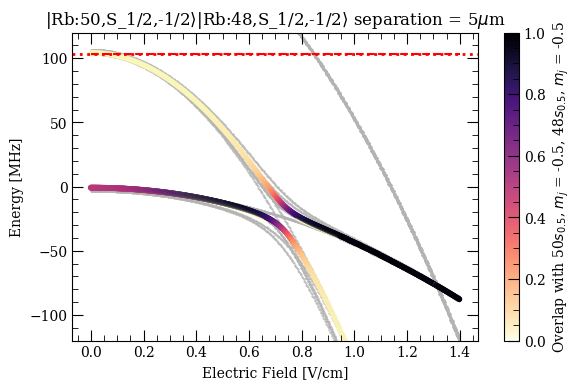

In [82]:


for i, d in enumerate(r):
    fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
    ax.set_xlabel("E_z (mV/cm)")
    ax.set_ylabel(f"Energy ({energy_unit})")
    ax.set_title(fr'separation {d} $\mu$m')
    # ax.set_ylim(-0.01, 0.01)

    # system_atom = system_atom_dict[efield]
    pair_energy = ket1_energy + ket2_energy
    system_pairs = system_pairs_dict[d]


    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    
    overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]

    # ax.plot(e_fields_sub, energies)
    for x, es in zip(e_fields_sub, energies):
        plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)



    # ax.set_ylim(- erange, + erange)
    # for x, es in zip(e_fields_sub, energies_0):
    #     ax[1].plot([x] * len(es), es, c='.1', ls="None", marker=".", ms=2, zorder=-10)
    
    # print(energies[0])
    # print(energies_0[0])
    # potential = []
    # for es1, es0 in zip(energies, energies_0):
    #     es = []
    #     es1, es0 = list(es1), list(es0)
    #     try:
    #         max1 = np.max(es1)
    #         max0 = np.max(es0)
    #         min1 = np.min(es1)
    #         min0 = np.min(es0)
    #         emax = max1 - max0
    #         emin = min1 - min0

    #         potential.append([emin,emax, emin+emax])
    #     except(ValueError):
    #         continue
    
    # for x, es in zip(e_fields_sub, potential):
    #     ax[1].plot([x] * len(es), es, c='.1', ls="None", marker=".", ms=2, zorder=-10)
    plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')

    plt.tight_layout()
    min_energy = -120
    
    max_energy = 120
    plt.title(fr'{str(ket1)}{str(ket2)} separation = {d}$\mu$m')
    plt.ylim(min_energy, max_energy)
    # plt.xlim(2, 2.7)
    plt.ylabel(f"Energy [{energy_unit}]")
    plt.xlabel("Electric Field [V/cm]")
    # 
    tunes=[]
    for eigenenergy in eigenenergies_pair:

        

    
        if eigenenergy[0] == state0s[0][0]:
            # ax.plot(electric_fields, eigenenergy, c='blue', lw=0.3, linestyle = 'dashed')
            continue
        elif round(abs(defect), 4) <= round(abs(eigenenergy[0]),4) <= round(abs(defect), 4):
            # ax.plot(electric_fields, eigenenergy, c='blue', lw=0.3, linestyle = 'dashed')
            for state0 in state0s:
                
                energy = eigenenergy-state0
                cross = min(energy, key=abs)
                if abs(cross) < 1:
                    index = list(energy).index(cross)
                    if index == 0 or index == len(electric_fields)-1:
                        continue
                    else:
                        tuned = electric_fields[index]
                        # ax.vlines(x=tuned, ymin = min_energy, ymax = eigenenergy[index], linestyles='dashed', colors='magenta', linewidth = 0.5)
                        tunes.append(format(round(tuned, 4), ".15g"))
        min_overlap = 0.000
    for x, es, os in zip(e_fields_sub, energies, overlaps):
        inds = np.argwhere(os > min_overlap).flatten()
        inds = inds[np.argsort(os[inds])]
        if len(inds) > 0:
            scat = plt.scatter(
                [x] * len(es[inds]),
                es[inds],
                c=os[inds],
                s=10,
                vmin=0,
                vmax=1,
                cmap=alphamagma,
            )
    fig.colorbar(scat, ax=ax, label=fr"Overlap with {ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$ = {ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$ = {ket2.m}")
    plt.hlines((min_defect), xmin=electric_fields[0], xmax=electric_fields[-1], color='red', linestyle='dashed')
    plt.show()
    fig.savefig(path + f'level pairstate sep{r}.png')